# Predicting Profitable Customer Groups

This notebook answers the three ML questions in the case study:

1. How often was Group 1, Group 2 or neither group profitable?
2. Which model should be used to support future targeting decisions?
3. How much could the model improve offline correct targeting decisions, and how should that improvement be validated online?

The model predicts one of three outcomes:

* `0`: neither group is likely to be profitable
* `1`: Group 1 is likely to be the most profitable
* `2`: Group 2 is likely to be the most profitable

Operationally, a class-0 prediction supports declining or manually reviewing the campaign rather than automatically targeting one group.

The model uses only the **67 pre-campaign variables**: `g1_1`–`g1_20`, `g2_1`–`g2_20` and `c_1`–`c_27`. The three post-campaign variables are excluded because they would not be available when the targeting decision is made. The supplied target is used directly; the anonymised feature values are not interpreted as ROI amounts.

| Stage                        |  Rows | Purpose                                                                                           |
| ---------------------------- | ----: | ------------------------------------------------------------------------------------------------- |
| Model training and selection | 4,236 | Five-fold CV, model comparison and fitting                                                        |
| Calibration                  | 1,060 | Calibration-method and confidence-threshold assessment; these rows do not train the Random Forest |
| Holdout                      | 1,324 | Final reporting after the champion and decision rules were fixed                                  |

**Final offline result:** the selected model is an uncalibrated Random Forest with **54.83% holdout accuracy**. This is an estimated **+8.38 percentage-point improvement in offline correct targeting decisions** over always choosing Group 1. It is not evidence of confirmed ROI improvement.

Model selection was based on development-data cross-validation, and the holdout did not change the selected champion. Because some exploratory analysis was performed before the split, the holdout is treated as a confirmation set rather than a completely untouched test set.

The notebook imports shared feature-processing and training functions from `src/`. The deployed API loads the resulting fitted pipeline, ensuring that training and inference follow the same feature contract.

Additional experiments are kept in `02_optional_diagnostics.ipynb`. They provide supporting analysis but do not change the selected model, deployed artifact or final result reported above.


In [1]:
# ruff: noqa: E402
import json
import sys
import warnings
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split

from notebooks.analysis_support import ( apply_calibration_rule, assert_column_contract, calibration_table, champion_verdict, data_quality_report, dataset_facts,
                                        feature_contract, gate_summary, leakage_association, leakage_cv_comparison, lift_summary, missing_values_report, 
                                        outcome_shares, outcome_table, plot_campaign_outcomes, plot_feature_distributions, plot_horizontal_importance, 
                                        plot_reliability, plot_strategies, show_confusion, show_time_ordering, split_summary, strategy_table, style_leaderboard,)

from src.calibration import compare_calibration_methods
from src.constants import TARGET_COLUMN
from src.explainability import permutation_importance_report
from src.training.diagnostics import operating_points, select_confidence_threshold
from src.training.evaluation import ( bootstrap_lift_interval, campaign_outcome_distribution, classification_metrics, estimate_business_lift,)
from src.training.pipeline import build_pipeline, candidate_models, split_features_target
from src.training.splits import make_split

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold"})

DATA_PATH = PROJECT_ROOT / "data" / "customerGroups.csv"
REPORTS = PROJECT_ROOT / "reports"
FIGURES = REPORTS / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
HOLDOUT_SEED = 20260819
BOOTSTRAP_N = 1000
RESULTS: dict = {}

def save_fig(fig, name: str) -> None:
    # Centralise figure export so the report and notebook use the same images.
    fig.savefig(FIGURES / name, dpi=150, bbox_inches="tight")

pd.DataFrame(
    {"value": [str(PROJECT_ROOT), DATA_PATH.exists(), RANDOM_STATE, HOLDOUT_SEED]},
    index=["project root", "dataset present", "model seed", "holdout seed"],
)


,value
project root,e:\dev\campaign-group-predictor
dataset present,True
model seed,42
holdout seed,20260819


---

## 1. Data contract and quality

Each row compares two customer groups considered for one campaign. The file contains 6,620 rows and 71 columns.

| Block | Columns | Available before launch? | Role |
|---|---:|---|---|
| Group 1 | `g1_1`–`g1_20` | Yes | Group 1 characteristics |
| Group 2 | `g2_1`–`g2_20` | Yes | Group 2 characteristics |
| Comparison | `c_1`–`c_27` | Yes | Anonymised comparison variables |
| Post-campaign | `g1_21`, `g2_21`, `c_28` | No | Excluded from modelling |
| Target | `Target` | No | Outcome to predict |

The first checks enforce this schema and report missing values and duplicate rows.


In [2]:

df = pd.read_csv(DATA_PATH) # Load the campaign data and fail early if it violates the expected 71-column schema.
assert_column_contract(df)

RESULTS.update(dataset_facts(df)) # Record reproducibility metadata, then display the pre-/post-campaign feature contract.
feature_contract()

,columns,count,usable at prediction time
block,,,
"group 1, pre-campaign",g1_1 … g1_20,20,yes
"group 2, pre-campaign",g2_1 … g2_20,20,yes
"comparison, pre-campaign",c_1 … c_27,27,yes
post-campaign,"g1_21, g2_21, c_28",3,NO — recorded after the campaign ran
target,target,1,label


In [3]:
# Summarise data-quality issues such as duplicate rows, duplicate feature patterns, missing targets, and unexpected values before starting the analysis.
data_quality_report(df)

,value
shape (rows × columns),"6,620 × 71"
columns missing vs. brief,none
columns extra vs. brief,none
columns containing nulls,0
overall null rate,0.0000%
fully duplicated rows,0
rows duplicated on features only,0


In [4]:
# Check for missing values across all columns before defining the preprocessing strategy.
missing_values_report(df)

,note
0,No missing values in any column.


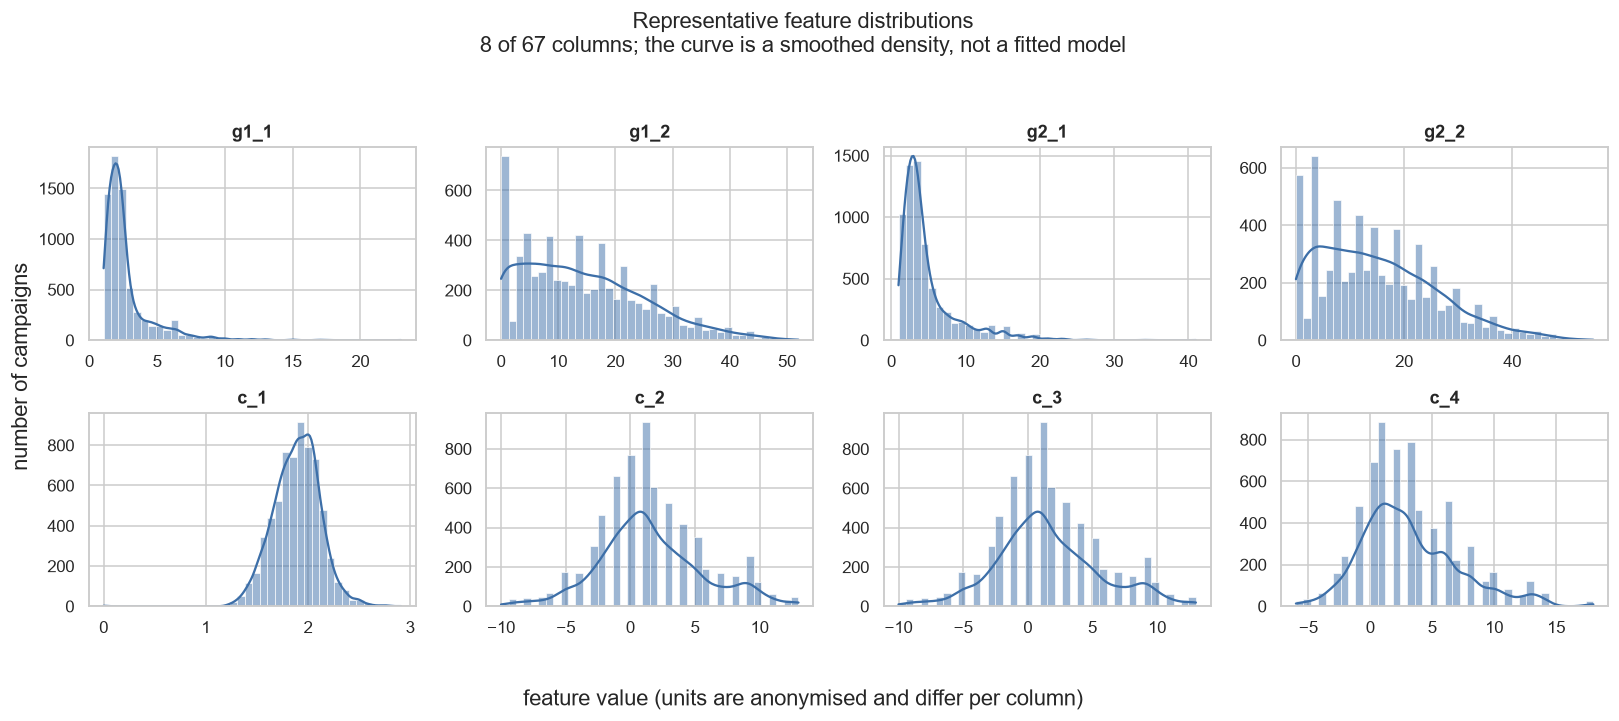

In [5]:
# Inspect feature ranges and distributions, then export the figure for reuse in the report.
fig = plot_feature_distributions(df)
save_fig(fig, "02_distributions.png")
plt.show()

**Finding.** The file matches the expected schema, contains no missing values, and has no exact duplicate rows. Feature scales and shapes vary, so preprocessing remains inside each model pipeline.

Two limitations remain: there is no campaign/customer identifier to verify independence between rows, and there is no campaign date for a temporal validation split. The anonymised columns also cannot be interpreted in business terms without a data dictionary.


---

## 2. ML Question 1 — historical campaign outcomes

The percentages come directly from counts in `Target`; no ROI formula is required because the label already records which outcome occurred.


In [6]:
# Count the three historical campaign outcomes, store their percentages for reporting, and display the class distribution as a readable table.
distribution = campaign_outcome_distribution(df[TARGET_COLUMN])
RESULTS["outcome_distribution"] = outcome_shares(distribution)
outcomes = outcome_table(distribution)
outcomes

,outcome,count,share of campaigns (%)
no_group_profitable,None of the two groups were profitable,1667,25.18
group_1,Group 1 was the most profitable,3076,46.47
group_2,Group 2 was the most profitable,1877,28.35


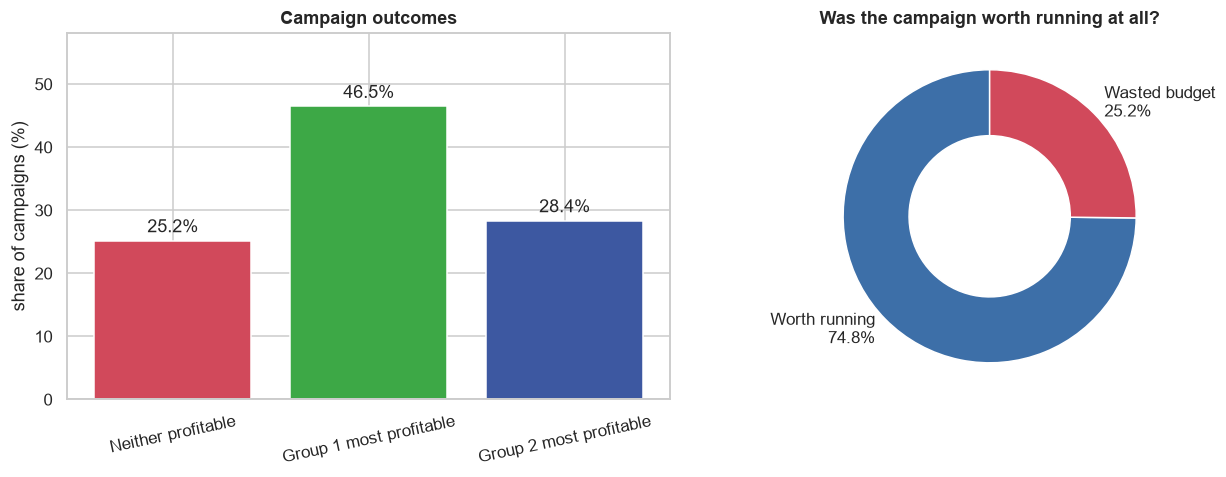

In [7]:
# Visualise the historical outcome distribution and save the chart for the final report.
fig = plot_campaign_outcomes(distribution)
save_fig(fig, "01_campaign_outcomes.png")
plt.show()

**Finding.** Of 6,620 campaigns, Group 1 was most profitable in **3,076 (46.47%)**, Group 2 in **1,877 (28.35%)**, and neither group was profitable in **1,667 (25.18%)**. Therefore, **always choose Group 1** is the strongest simple baseline at approximately 46.5%.


---

## 3. Prediction-time boundary and leakage control

`g1_21`, `g2_21`, and `c_28` are recorded after a campaign. They are excluded because they are unavailable when the recommendation is made. This is temporal/availability leakage even if their statistical association with the target is weak.

The following diagnostic quantifies their apparent signal, then removes them before any model selection.


In [8]:
# Diagnose whether the three post-campaign columns are associated with the target.
# They remain excluded because they are unavailable when a prediction is required.
leakage_association(df)

,correlation with target,mean | class 0,mean | class 1,mean | class 2
g1_21,-0.0478,0.4528,0.4562,0.4352
g2_21,-0.0018,3.6886,4.1308,3.7073
c_28,0.0214,1.8668,1.9616,1.8891


In [9]:
# Compare cross-validation performance with and without post-campaign columns to quantify their apparent score impact; this is diagnostic only and does not justify using them.
leak = leakage_cv_comparison(df, RANDOM_STATE)
RESULTS["leakage_inflation_f1"] = leak.inflation_f1
leak.table

KEEPING post-campaign columns ['g1_21', 'g2_21', 'c_28']. This is valid only for the leakage demonstration - a model trained on these cannot be deployed, because the values do not exist when a campaign is being planned.


,features,CV macro F1,std
with post-campaign columns,70,0.4907,0.0127
pre-campaign only (used from here),67,0.4869,0.0098


In [10]:
# Separate predictors from the target and exclude all post-campaign columns because they are unavailable when a future targeting decision is made.
X, y = split_features_target(df, drop_leakage=True)
print(f"{X.shape[1]} pre-campaign features, {len(y)} campaigns")

67 pre-campaign features, 6620 campaigns


**Finding.** Adding the three post-campaign columns changes diagnostic CV macro F1 by only **+0.0038**, but score impact is not the criterion. They do not exist at prediction time, so the trained and deployed model uses exactly **67 pre-campaign features**.


---

## 4. Evaluation design

The modelling protocol is fixed before the holdout result is inspected:

1. Create a stratified 80% development / 20% holdout split.
2. Reserve part of development data as a calibration set.
3. Compare candidate models with five-fold stratified CV on the training portion.
4. Select the champion by mean CV accuracy; report macro F1, balanced accuracy, and per-class recall as secondary metrics.
5. Fit calibration methods and optional confidence thresholds using only the calibration set.
6. Evaluate the locked model on the holdout and reuse those predictions for reporting.

Class imbalance is addressed with class-weighted estimators where supported. Resampling is not used because it would change the observed campaign prior. Macro and per-class metrics expose performance that overall accuracy can hide.


In [11]:
# No campaign date is available, so check whether any numeric feature behaves like a hidden chronological index. 
# Use a temporal split only if a credible proxy is found.
timing = show_time_ordering(X)
SPLIT_STRATEGY, ORDER_BY = timing.strategy, timing.order_by
RESULTS["split_strategy"] = timing.strategy
RESULTS["time_ordering_candidates"] = timing.candidates
print(f"Split strategy: {SPLIT_STRATEGY}")

,spearman_with_row_order,monotonic_fraction,n_unique,looks_like_time
column,,,,
c_24,-0.029,0.928,5,False
c_4,0.004,0.546,22,False
c_2,-0.020,0.541,24,False
c_3,0.021,0.538,24,False
c_13,-0.008,0.532,67,False
g1_10,-0.028,0.526,74,False
c_10,-0.037,0.526,67,False
c_14,0.013,0.526,53,False


,decision
time-ordering candidates,none detected
split strategy adopted,stratified


Split strategy: stratified


In [12]:
# Reserve 20% as the held-out confirmation set. The selected split strategy is determined above; in this dataset it falls back to a stratified random split.

X_dev, X_test, y_dev, y_test = make_split( X, y, strategy=SPLIT_STRATEGY, test_size=0.2, random_state=HOLDOUT_SEED, order_by=ORDER_BY,)

# Split the remaining development data into model-training (64% overall) and calibration (16% overall) partitions while preserving class proportions.

X_train, X_calib, y_train, y_calib = train_test_split( X_dev, y_dev, test_size=0.2, stratify=y_dev, random_state=RANDOM_STATE,)

# Symmetry augmentation is disabled because the anonymised comparison columns do not provide a reliable transformation contract when the groups are swapped.

X_fit, y_fit = X_train, y_train

# Use the same shuffled, stratified five-fold CV protocol for every candidate model.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Store the evaluation protocol so reports can reproduce and verify the split.
RESULTS["cv_protocol"] = type(cv).__name__
RESULTS["holdout_seed"] = HOLDOUT_SEED
RESULTS["augmentation_applied"] = False

split_summary( len(X_train), len(X_fit), len(X_calib), len(X_test), False,)

,rows,purpose
train,4236,training campaigns
fit,4236,augmentation disabled
calibration,1060,"calibration (held out; calibrator, thresholds ..."
test,1324,"test (evaluated once, on the champion only)"


No usable temporal proxy was detected, so the analysis uses a stratified random split. This supports held-out generalisation under an i.i.d. assumption; it does **not** establish performance on future campaigns. A campaign date and stable group identifier are required for stronger temporal and grouped validation.


In [13]:
# Compare every candidate using identical folds and metrics. 
# Accuracy is the predefined primary selection metric; macro F1 and balanced accuracy are reported as secondary metrics to expose performance across the imbalanced classes.

SCORERS = {"accuracy": "accuracy","f1_macro": "f1_macro", "balanced_accuracy": "balanced_accuracy",}
SELECT_BY = "CV accuracy"

records, fitted = [], {}

for name, model in candidate_models(RANDOM_STATE).items():
    # Keep preprocessing inside the pipeline so it is fitted independently within each CV fold and cannot leak validation information.
    pipeline = build_pipeline(model)

    # Evaluate every candidate on exactly the same five stratified folds.
    cv_result = cross_validate( pipeline, X_fit, y_fit, cv=cv, scoring=SCORERS,)

    # Fit each candidate on all training rows after CV. The selected fitted pipeline will later be used for calibration and holdout reporting.
    pipeline.fit(X_fit, y_fit)
    fitted[name] = pipeline

    records.append(
        {
            "model": name, "CV accuracy": cv_result["test_accuracy"].mean(),
            "CV std": cv_result["test_accuracy"].std(),
            "CV macro F1": cv_result["test_f1_macro"].mean(),
            "CV balanced acc": cv_result["test_balanced_accuracy"].mean(),
        }
    )

# Rank candidates using only the predefined CV accuracy—not holdout performance.

leaderboard = ( pd.DataFrame(records).sort_values(SELECT_BY, ascending=False).set_index("model"))
style_leaderboard(leaderboard)

,CV accuracy,CV std,CV macro F1,CV balanced acc
model,,,,
random_forest,0.5781,0.0051,0.4854,0.5128
xgboost,0.5741,0.0090,0.4941,0.5112
catboost,0.5656,0.0088,0.5166,0.5253
hist_gradient_boosting,0.5649,0.0067,0.4910,0.5059
mlp,0.5626,0.0183,0.4654,0.4962
lightgbm,0.5590,0.0124,0.4962,0.5064
logistic_regression,0.5229,0.0181,0.5023,0.5055


In [14]:
# Select the highest-ranked model from cross-validation automatically.
# The holdout set is not consulted during this decision.
AUTOMATIC_CHAMPION = leaderboard.index[0]

# Keep a separate final champion variable so any manual override would be explicit.
# No override is applied in this analysis.
CHAMPION = AUTOMATIC_CHAMPION
champion = fitted[CHAMPION]

# Record both values to make the selection process auditable.
RESULTS["champion"] = CHAMPION
RESULTS["automatic_champion"] = AUTOMATIC_CHAMPION
RESULTS["champion_overridden"] = False

champion_verdict(leaderboard, CHAMPION)

,value
"champion (CV accuracy, no override)",random_forest
its CV accuracy,0.5781
gap to runner-up,0.0040
combined CV std,0.0141
verdict,within noise — the top models are not separable


**Finding.** Random Forest has the highest mean CV accuracy (**57.81%**) and is selected automatically with no manual override. Its margin over XGBoost is only **0.40 percentage points**, so this result supports the predefined selection rule; it does not prove Random Forest is universally superior.


---

## 5. Final holdout evaluation

The champion is now fixed. The holdout is used to estimate generalisation and to report the confusion matrix and class-level metrics.


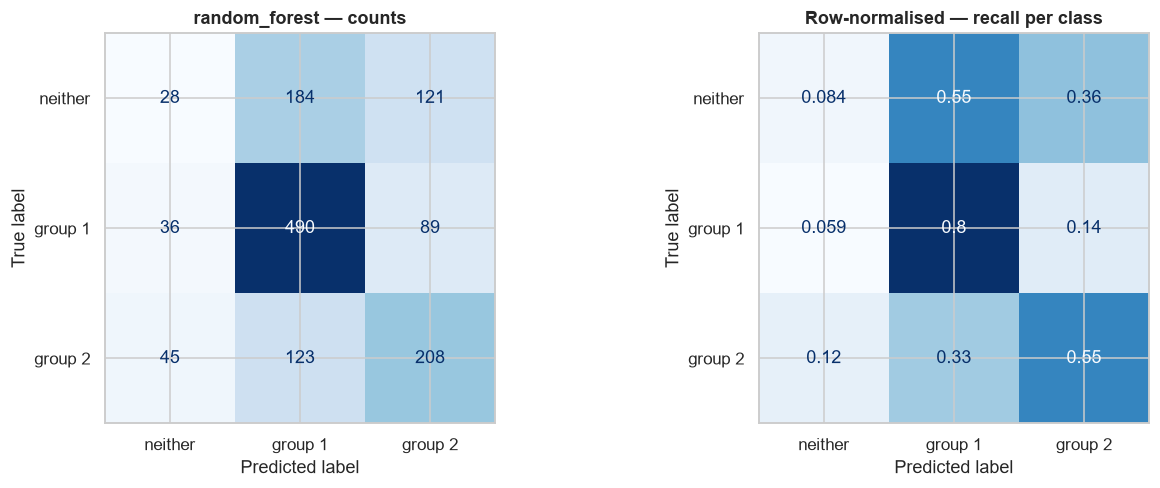

,precision,recall,f1-score,support
neither,0.2569,0.0841,0.1267,333
group 1,0.6148,0.7967,0.6941,615
group 2,0.4976,0.5532,0.5239,376
accuracy,0.5483,0.5483,0.5483,1
macro avg,0.4564,0.4780,0.4482,1324
weighted avg,0.4915,0.5483,0.5030,1324


In [15]:
# Evaluate the CV-selected champion on the held-out confirmation set.
# Later calibration analysis is performed separately and does not use these results to change the selected model.

predictions = champion.predict(X_test)

# Display and export the confusion matrix with class-level metrics.
fig, report = show_confusion(y_test, predictions, CHAMPION)
save_fig(fig, "04_confusion_matrix.png")
plt.show()

# Report overall and class-sensitive metrics because accuracy alone can hide weak performance on the minority "neither profitable" class.
test_metrics = classification_metrics(y_test.to_numpy(), predictions)
CHAMPION_TEST_ACCURACY = round(float(test_metrics["accuracy"]), 4)

RESULTS["success_rate_model"] = CHAMPION_TEST_ACCURACY
RESULTS["macro_f1"] = test_metrics["f1_macro"]
RESULTS["balanced_accuracy"] = test_metrics["balanced_accuracy"]
RESULTS["per_class_recall"] = {
    name: round(float(report.loc[name, "recall"]), 4)
    for name in ["neither", "group 1", "group 2"]
}

# Format the classification report for clear notebook display.
report.style.format( "{:.4f}", subset=["precision", "recall", "f1-score"], ).format("{:.0f}", subset=["support"],)

| Holdout metric | Result |
|---|---:|
| Accuracy | **54.83%** |
| Macro F1 | **44.82%** |
| Balanced accuracy | **47.80%** |
| Recall — neither profitable | **8.41%** |
| Recall — Group 1 | **79.67%** |
| Recall — Group 2 | **55.32%** |

**Finding.** The model improves overall targeting accuracy but rarely identifies campaigns where neither group is profitable. The low class-0 recall is the principal modelling risk and must remain visible alongside the headline accuracy.

The holdout was not used to choose the champion. However, descriptive EDA was performed on the full file and the same holdout predictions are reused below for several reports. It is therefore best described as a **held-out confirmation set**, not a completely unseen or “virgin” test set.


---

## 6. Probability calibration

The calibration set is separate from model fitting. One half fits candidate calibrators; the other half selects a method. Calibration is adopted only if expected calibration error (ECE) improves by at least 10%.


In [16]:
# Divide the calibration partition into two stratified halves: one to fit candidate calibrators and one to compare them independently.
# These rows are not used to train or select the underlying Random Forest.

X_cal_fit, X_cal_eval, y_cal_fit, y_cal_eval = train_test_split( X_calib, y_calib, test_size=0.5, stratify=y_calib, random_state=RANDOM_STATE,)

# Fit the candidate calibration methods on X_cal_fit and evaluate their probability quality on the separate X_cal_eval partition.

comparison = compare_calibration_methods( champion, X_cal_fit, y_cal_fit, X_cal_eval, y_cal_eval,)

# Record where calibration-method selection occurred for reproducibility.
RESULTS["calibration_selected_on"] = ( f"held-out half of calibration split (n={len(X_cal_eval)})")
calibration_table(comparison)

,expected calibration error,max calibration error,Brier score,log loss
uncalibrated,0.0530,0.9289,0.5486,0.9274
isotonic,0.0498,0.1056,0.5528,0.9328
sigmoid,0.0521,0.0859,0.5458,0.9223


In [17]:
# Apply the predefined calibration-adoption rule using the comparison results.
# If no method provides sufficient improvement, the original champion is retained.

calibration = apply_calibration_rule( comparison, champion, X_cal_fit, y_cal_fit,)

# Store the model selected by the calibration rule. In this analysis, calibration is rejected, so final_model is the original Random Forest.

final_model = calibration.model

# Record the selected calibration method for reporting and reproducibility.
RESULTS["calibration_method"] = calibration.method
calibration.verdict

,value
lowest-ECE method on the selection half,isotonic
ECE uncalibrated,0.0530
ECE calibrated,0.0498
relative improvement,6.1%
improvement required,10%
decision,REJECTED — improvement is within noise


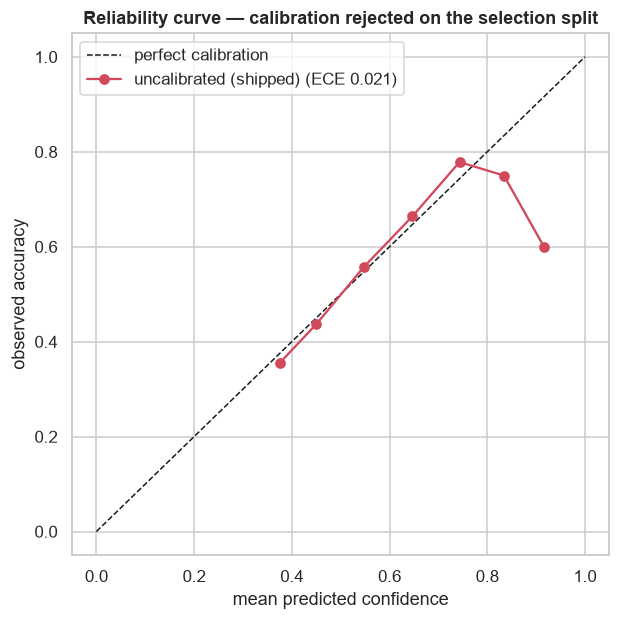

In [18]:
# Report holdout reliability only after the calibration rule has been frozen.
# The helper always plots the original champion and adds a calibrated curve only when calibration was accepted. Here calibration was rejected, so it displays only the uncalibrated Random Forest that is actually shipped.
fig = plot_reliability( y_test, champion, X_test, calibration,)

# Export the reliability diagram for reuse in the report.
save_fig(fig, "05_calibration.png")
plt.show()

**Finding.** Isotonic calibration improves selection-split ECE by **6.1%**, below the predefined 10% adoption threshold, so calibration is rejected. The shipped model remains the uncalibrated Random Forest. API confidence values are model scores and must not be described as profit or ROI probabilities.


---

## 7. Explainability and decision support

Permutation importance is computed on the calibration set, not the holdout. It measures the drop in macro F1 when a feature is shuffled.


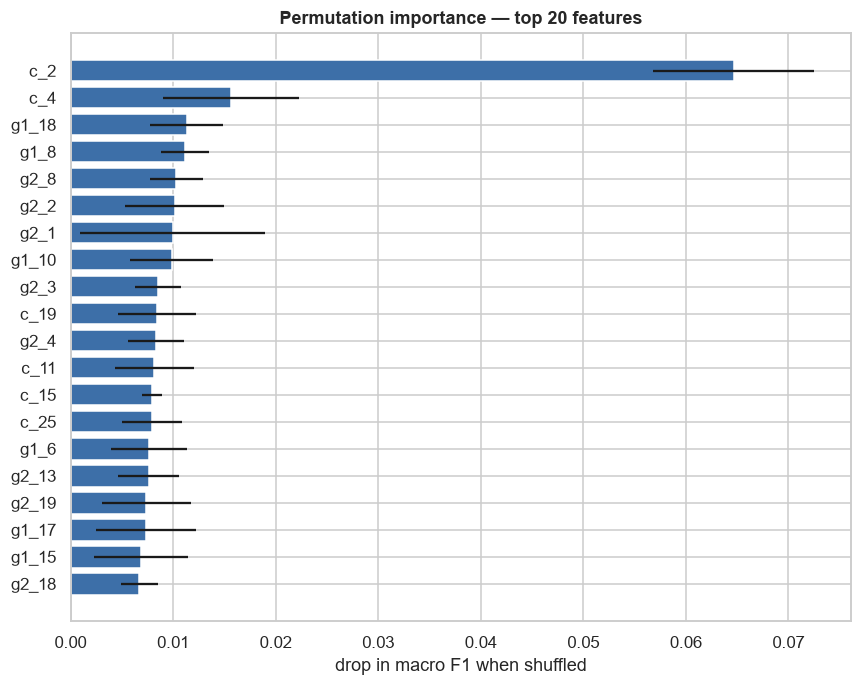

,importance_mean,importance_std,rank
feature,,,
c_2,0.06466,0.00785,1
c_4,0.01568,0.00664,2
g1_18,0.01132,0.00359,3
g1_8,0.01116,0.00233,4
g2_8,0.01030,0.00259,5
g2_2,0.01017,0.00482,6
g2_1,0.00995,0.00906,7
g1_10,0.00986,0.00405,8
g2_3,0.00853,0.00229,9


In [19]:
# Measure feature importance on the calibration partition rather than the holdout. 
# Importance is the decrease in macro F1 after each feature is shuffled.
perm = permutation_importance_report( champion, X_calib, y_calib, n_repeats=10, random_state=RANDOM_STATE,)

# Store the ten highest-ranked raw input features for consistent reporting.
RESULTS["top_features_clean"] = perm.head(10).index.tolist()

# Visualise the top 20 features. Error bars show variation across the ten permutation repeats and help distinguish stable importance from noise.

fig = plot_horizontal_importance( perm, "importance_mean", "Permutation importance — top 20 features", "drop in macro F1 when shuffled", error_column="importance_std",)

save_fig(fig, "06_permutation_importance.png")
plt.show()

# Display a compact table containing the ten most important features.
perm.head(10).style.format({"importance_mean": "{:.5f}", "importance_std": "{:.5f}",})

**Finding.** `c_2` is the most influential predictor for this model. Because all feature meanings are anonymised and several inputs may be correlated, importance is predictive rather than causal. The correct next step is to obtain the data dictionary and review `c_2` with the data owner—not to attach a business explanation to an unknown variable.


### Optional confidence gate

A threshold selected on the calibration set explores whether low-confidence cases should be routed for manual review. This is a decision-support experiment, not the primary model metric and not evidence of ROI.


In [20]:
# Calculate the full-holdout accuracy of the strongest simple policy: always recommend Group 1.
NAIVE_BASELINE = float((y_test == 1).mean())

# Select the confidence threshold using calibration data only. The rule chooses the highest covered-case accuracy while retaining at least 30% coverage.

gate = select_confidence_threshold( y_calib.to_numpy(), final_model.predict_proba(X_calib), min_coverage=0.30,)

# Store the frozen threshold and its calibration-set operating point.
RESULTS["automation_gate"] = gate

# Apply the already-selected threshold to the holdout probabilities for reporting. 
# Calibration was rejected, so these are uncalibrated model confidence scores.
test_probabilities = final_model.predict_proba(X_test)

ops_test = operating_points(y_test.to_numpy(), test_probabilities, thresholds=[0.0, gate["threshold"]],)

# Identify the holdout rows that the model would handle automatically.
covered = test_probabilities.max(axis=1) >= gate["threshold"]

# Evaluate Always-Group-1 on the same covered rows for a fair comparison.
gated_baseline = float((y_test.to_numpy()[covered] == 1).mean())

# Store the holdout operating points and same-subset baseline for reporting.

RESULTS["automation_gate_on_test"] = ops_test.reset_index().to_dict(orient="records")
RESULTS["gated_group_1_baseline"] = gated_baseline

# Display the selected rule and its holdout coverage–accuracy trade-off.
display(gate_summary(gate))
ops_test.style.format({"coverage": "{:.1%}", "accuracy_covered": "{:.4f}",})

,value
threshold (chosen on calibration),0.6
coverage (calibration),33.2%
accuracy (calibration),0.7386
selection rule,best accuracy subject to coverage >= 30%


,coverage,n_decided,n_escalated,accuracy_covered,accuracy_overall
min_confidence,,,,,
0.000000,100.0%,1324,0,0.5483,0.548300
0.600000,34.8%,461,863,0.7158,0.548300


**Finding.** The 0.60 confidence threshold was selected on calibration data using the predefined
rule of maximising accuracy subject to at least 30% coverage. It achieved **73.86% accuracy at
33.21% coverage** on calibration data. Applied unchanged to the holdout, it achieved **71.58%
accuracy at 34.82% coverage** (461 of 1,324 campaigns). Always choosing Group 1 achieved **57.48%
on those same 461 campaigns**, giving a **+14.10 percentage-point same-subset accuracy
difference**. This is a selective operating point — not the model's full-coverage accuracy — and
requires operational and online validation before automation.

---

## 8. ML Question 3 — estimated improvement

Offline success means the predicted action equals the supplied historical outcome. The model is compared with simple policies on the same holdout rows. Because campaign-level revenue and cost are unavailable, this section estimates better decisions—not monetary ROI.


In [21]:
# Generate the final holdout predictions using the model returned by the frozen calibration decision. 
# In this analysis, it is the uncalibrated Random Forest.
final_predictions = final_model.predict(X_test)

# Compare the model's offline correct-decision rate with the strongest simple policy on the same holdout rows. This is not a monetary ROI calculation.

lift = estimate_business_lift( y_test.to_numpy(), final_predictions,)

# Quantify uncertainty by repeatedly resampling paired target–prediction rows.
# The strongest simple baseline is recalculated within every bootstrap sample.
ci = bootstrap_lift_interval( y_test.to_numpy(), final_predictions, n_resamples=BOOTSTRAP_N, random_state=RANDOM_STATE,)

# Store the canonical holdout result and confidence interval for downstream consistency checks, documentation and presentation generation.
RESULTS["success_rate_model"] = lift.model_success_rate
RESULTS["best_naive_strategy"] = lift.best_naive_strategy
RESULTS["best_naive_success_rate"] = lift.best_naive_success_rate
RESULTS["lift_pp"] = lift.absolute_lift_pp
RESULTS["lift_ci_pp"] = [ ci["ci_lower_pp"], ci["ci_upper_pp"],]
RESULTS["significantly_positive"] = ci["significantly_positive"]

# Display the model and simple-policy success rates on the same holdout set.
strategies = strategy_table(lift, CHAMPION)
strategies.style.format( "{:.2%}").bar(color="#3e814d").highlight_max(color="#c8e6c9")

,success rate
random choice between groups,37.42%
always target group 1,46.45%
always target group 2,28.40%
run no campaigns at all,25.15%
MODEL (random_forest),54.83%


In [22]:
# Display the headline offline lift, its 95% bootstrap confidence interval, statistical significance and the number of unprofitable campaigns correctly declined.

lift_summary(lift, ci, BOOTSTRAP_N)

,value
best naive strategy,always_group_1
its success rate,46.45%
model success rate,54.83%
absolute lift,+8.38 pp
95% bootstrap CI (1000 resamples),+5.66 to +11.18 pp
statistically above zero,yes
unprofitable campaigns correctly declined,28 (8.4%)


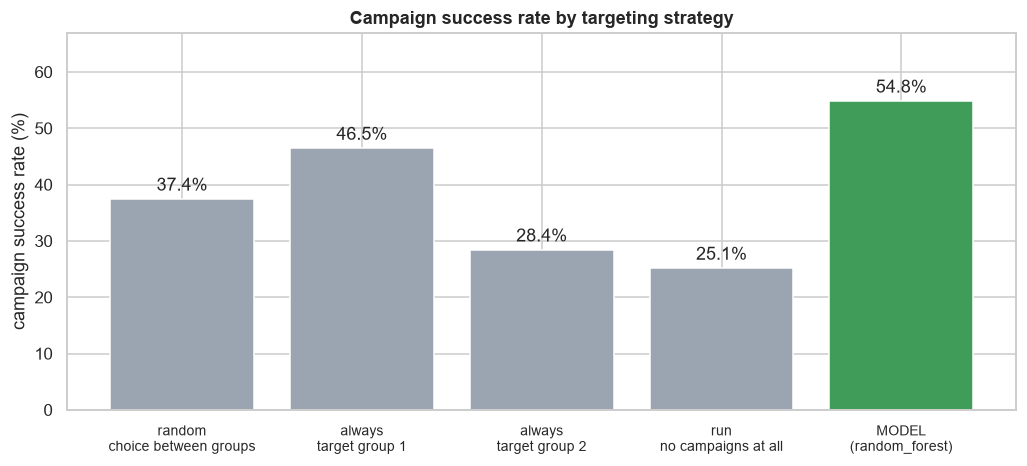

In [23]:
# Compare the final model with all simple targeting policies in one chart, then export the figure for reuse in the report and presentation.

fig = plot_strategies(strategies)
save_fig(fig, "08_success_rate.png")
plt.show()

**Answer.** Always choosing Group 1 succeeds on **46.45%** of holdout campaigns. The model succeeds on **54.83%**, an estimated improvement of **+8.38 percentage points** with a paired bootstrap 95% CI of **[+5.66, +11.18]**. The model correctly declines only **28 of 333** unprofitable campaigns, reinforcing the class-0 weakness.

This is best reported as **estimated improvement in offline correct targeting decisions**. It is not confirmed ROI because the dataset does not contain campaign cost, margin, treatment effects, or counterfactual outcomes.


### Online validation plan

Before changing budget allocation, run a controlled experiment:

1. Randomise eligible campaign decisions between the current business policy (control) and model-assisted policy (treatment).
2. Pre-register the minimum detectable effect, sample size, test duration, and promotion threshold.
3. Use realised net contribution or ROI as the primary KPI; track spend, contact rate, decline rate, and customer-impact metrics as guardrails.
4. Analyse by intention to treat and report confidence intervals, not only point estimates.
5. Promote only if business value improves without breaching guardrails; otherwise retain the current policy.

Campaign dates and stable campaign/group identifiers should be added before retraining so temporal and grouped validation become possible.


---

## 9. Conclusion and exported findings

The Random Forest is the reproducible CV winner and improves offline decision accuracy over the strongest simple baseline. The largest unresolved model risk is failure to identify the “neither profitable” class. Recommended next steps are shadow deployment, an online controlled test, recovery of the feature data dictionary, and collection of campaign dates and stable identifiers.


In [24]:
# Export the final verified results only after all analysis sections have completed.
# These machine-readable files keep the notebook, report and presentation consistent.

(REPORTS / "findings.json").write_text( json.dumps(RESULTS, indent=2, default=str), encoding="utf-8",)

# Export the model-comparison leaderboard and historical campaign outcomes as separate tables for documentation and consistency checks.
leaderboard.to_csv(REPORTS / "model_leaderboard.csv")
outcomes.data.to_csv(REPORTS / "campaign_outcomes.csv")

print("Exported findings.json, model_leaderboard.csv, and campaign_outcomes.csv")


Exported findings.json, model_leaderboard.csv, and campaign_outcomes.csv


### Final decision

- **Model:** uncalibrated Random Forest using 67 pre-campaign features
- **Offline accuracy:** 54.83%
- **Estimated offline lift:** +8.38 percentage points vs. always choosing Group 1
- **Primary risk:** 8.41% recall for campaigns where neither group is profitable
- **Deployment posture:** validate in shadow mode and then through a pre-registered controlled experiment before moving campaign budget
